In [1]:
import torch
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

from visual_search import VisualSearchModel
from gist import Gist
from backbone import ConvGist, VGG
from dataset_handler import COCODatasetHandler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

coco = COCODatasetHandler("../CoCo", "train2017")
IMG_SIZE = 256
BACKBONE_WEIGHTS_PATH = "models/best_convgist_model.pth"

/home/julian/Projects/KEMAI/iconic-visual-search/.venv/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/julian/Projects/KEMAI/iconic-visual-search/.venv/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or b

Using device: cuda
loading annotations into memory...
Done (t=4.15s)
creating index...
index created!


In [ ]:
target_batch = coco.find_instances("person", 500, max_area=1200, min_area=1000)
prototype = target_batch[5:]
test_images = target_batch[:5]

In [22]:
gist_model = Gist(
    in_channels=1,
    stride=4,
    pooling=None,  # NO pooling to maintain 64x64 spatial resolution
    flatten=False
)
gist_model.eval()
gist_model.to(device)

for param in gist_model.parameters():
    param.requires_grad = False

# Get output shape
with torch.no_grad():
    dummy_input = torch.randn(1, 1, IMG_SIZE, IMG_SIZE).to(device)  # 1 channel for grayscale
    gist_features = gist_model(dummy_input)
    print(f"Gist features shape (unflattened): {gist_features.shape}")
    gist_channels = gist_features.shape[1]
    
    # Expected: (1, 49, 64, 64) or similar
    # With defaults: 4 scales x 6 orientations x 2 phases + 1 Gaussian = 49 channels

print(f"Gist output channels: {gist_channels}")
print(f"Spatial dimensions: {gist_features.shape[2]}x{gist_features.shape[3]}")

# Initialize ConvGist model with linear classifier
num_classes = 80
backbone = ConvGist(
    in_channels=gist_channels,
    n_classes=num_classes,
    classifier="linear"
)
backbone.to(device)

model = VisualSearchModel(gist_model, backbone, device=str(device), img_size=(IMG_SIZE, IMG_SIZE))

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])

Gist features shape (unflattened): torch.Size([1, 97, 64, 64])
Gist output channels: 97
Spatial dimensions: 64x64


In [23]:
# Convert prototype list to PyTorch batch (directly from numpy, no PIL)
import torch.nn.functional as F

# Prepare batch data
batch_images = []
batch_bboxes = []

for instance in prototype:
    # Get image
    img = instance['image']
    
    # Convert PIL to numpy if needed
    if hasattr(img, 'convert'):  # PIL Image
        img = np.array(img.convert('L'))
    
    # Store original dimensions for bbox scaling
    orig_height, orig_width = img.shape[:2]
    
    # Convert numpy array directly to tensor
    if len(img.shape) == 2:
        # Grayscale: (H, W) -> (1, H, W)
        img_tensor = torch.from_numpy(img).float().unsqueeze(0)
    elif len(img.shape) == 3:
        # RGB: (H, W, C) -> (C, H, W)
        img_tensor = torch.from_numpy(img).float().permute(2, 0, 1)
    
    # Normalize to [0, 1] if needed
    if img_tensor.max() > 1.0:
        img_tensor = img_tensor / 255.0
    
    # Resize to IMG_SIZE using interpolate
    # Add batch dimension: (1, C, H, W)
    img_tensor = img_tensor.unsqueeze(0)
    img_tensor = transform(img_tensor)
    # Remove batch dimension: (C, H, W)
    img_tensor = img_tensor.squeeze(0)
    
    batch_images.append(img_tensor)
    
    # Transform bounding box coordinates from original to resized image space
    bbox_orig = instance['bbox_dict']
    scale_x = IMG_SIZE / orig_width
    scale_y = IMG_SIZE / orig_height
    
    bbox_transformed = {
        'x1': bbox_orig['x1'] * scale_x,
        'y1': bbox_orig['y1'] * scale_y,
        'x2': bbox_orig['x2'] * scale_x,
        'y2': bbox_orig['y2'] * scale_y
    }
    batch_bboxes.append(bbox_transformed)

# Stack into a batch tensor
prototype_batch = torch.stack(batch_images).to(device)
print(f"Prototype batch shape: {prototype_batch.shape}")
print(f"Number of bounding boxes: {len(batch_bboxes)}")
print(f"Example bbox (original → transformed): {instance['bbox_dict']} → {batch_bboxes[-1]}")

Prototype batch shape: torch.Size([495, 1, 256, 256])
Number of bounding boxes: 495
Example bbox (original → transformed): {'x1': 78.66, 'y1': 399.34, 'x2': 130.3, 'y2': 431.57} → {'x1': 31.464, 'y1': 212.9813333333333, 'x2': 52.120000000000005, 'y2': 230.17066666666665}


In [24]:
model.memorize_target_batch(prototype_batch, batch_bboxes)

Memorized target from 495 instances
Response mean range: [0.1541, 0.6600]
Response variance range: [0.2092, 0.7058]


  Fixations: 3
    Fixation 1: (68, 205) - Distance: 348.5px
    Fixation 2: (32, 175) - Distance: 391.8px
    Fixation 3: (21, 18) - Distance: 475.4px
  Final distance to target: 475.4 pixels


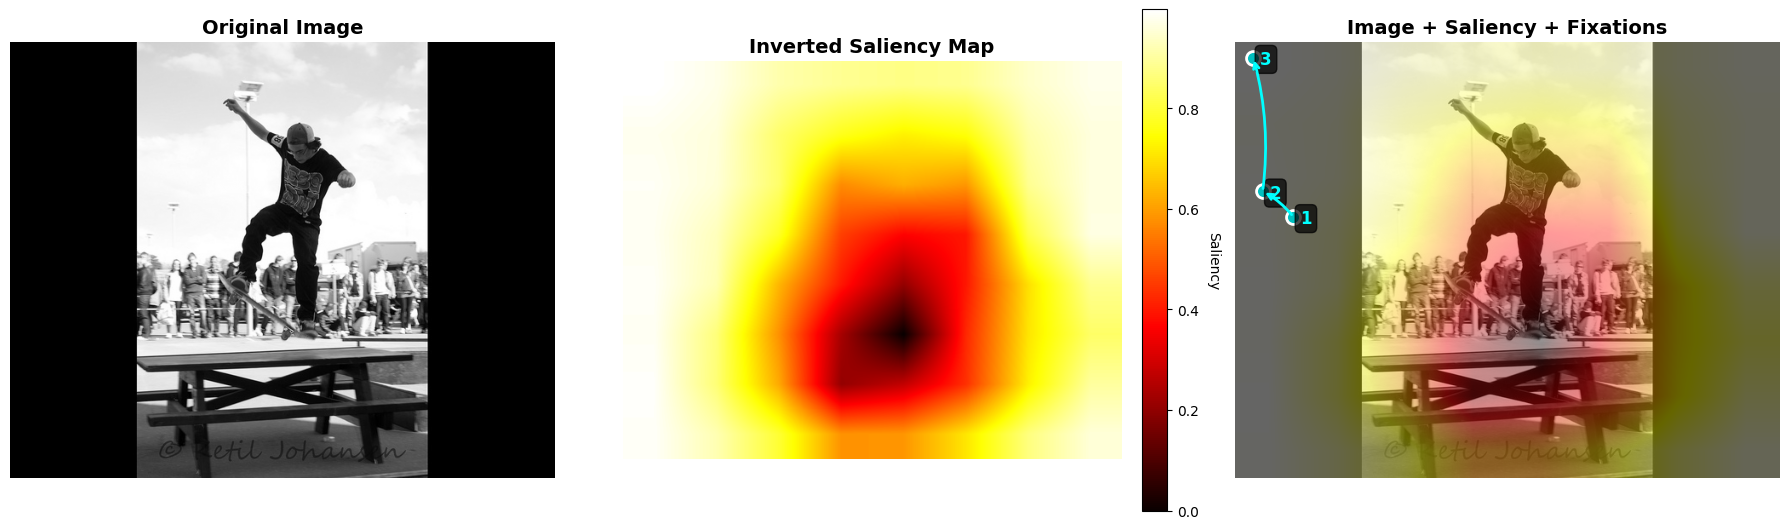

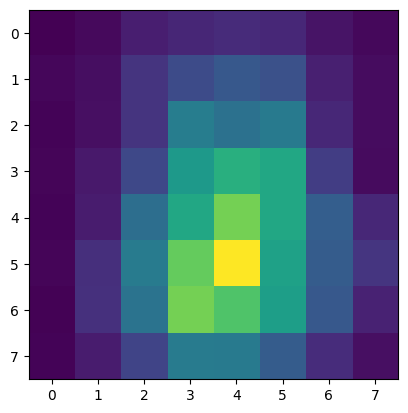

  Fixations: 3
    Fixation 1: (25, 17) - Distance: 679.4px
    Fixation 2: (21, 15) - Distance: 683.9px
    Fixation 3: (20, 13) - Distance: 685.7px
  Final distance to target: 685.7 pixels


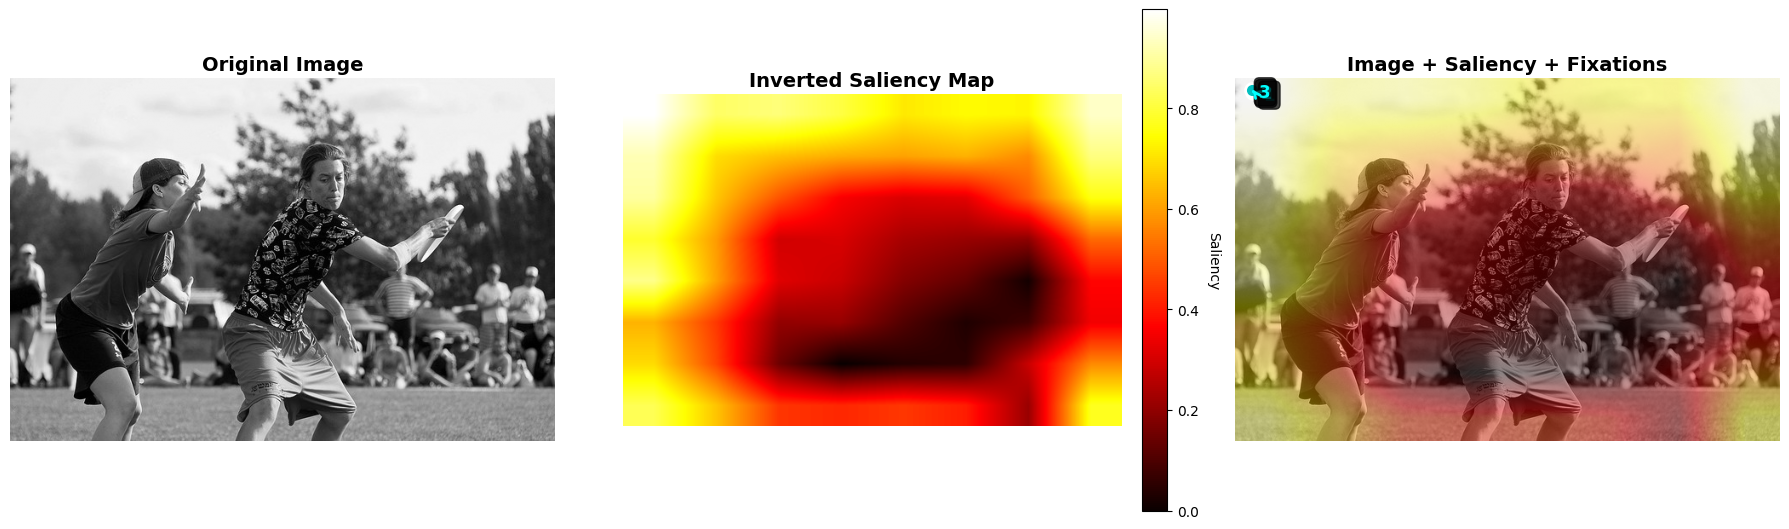

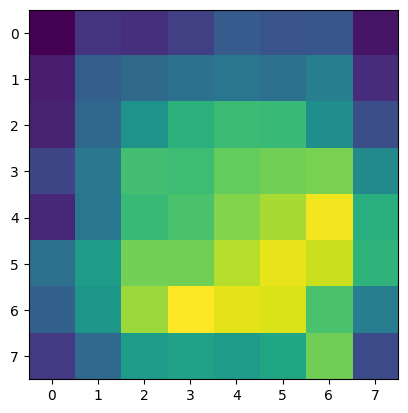

  Fixations: 3
    Fixation 1: (25, 17) - Distance: 308.2px
    Fixation 2: (21, 15) - Distance: 312.0px
    Fixation 3: (20, 13) - Distance: 314.2px
  Final distance to target: 314.2 pixels


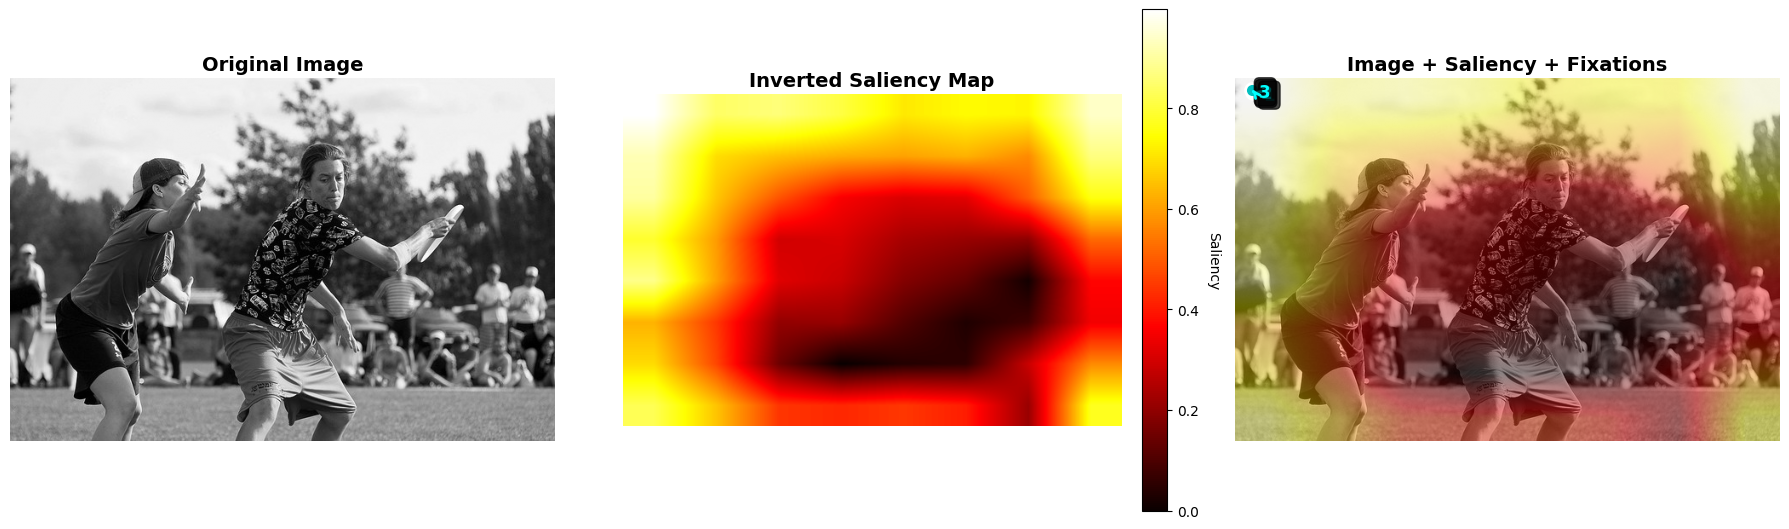

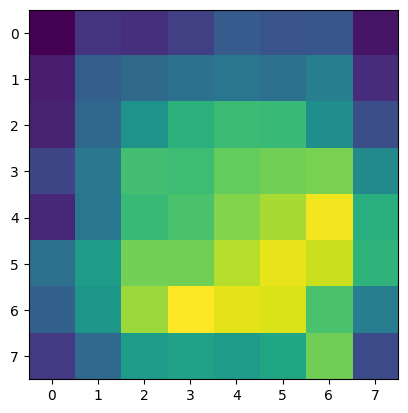

  Fixations: 3
    Fixation 1: (65, 375) - Distance: 252.1px
    Fixation 2: (24, 429) - Distance: 311.3px
    Fixation 3: (15, 439) - Distance: 323.8px
  Final distance to target: 323.8 pixels


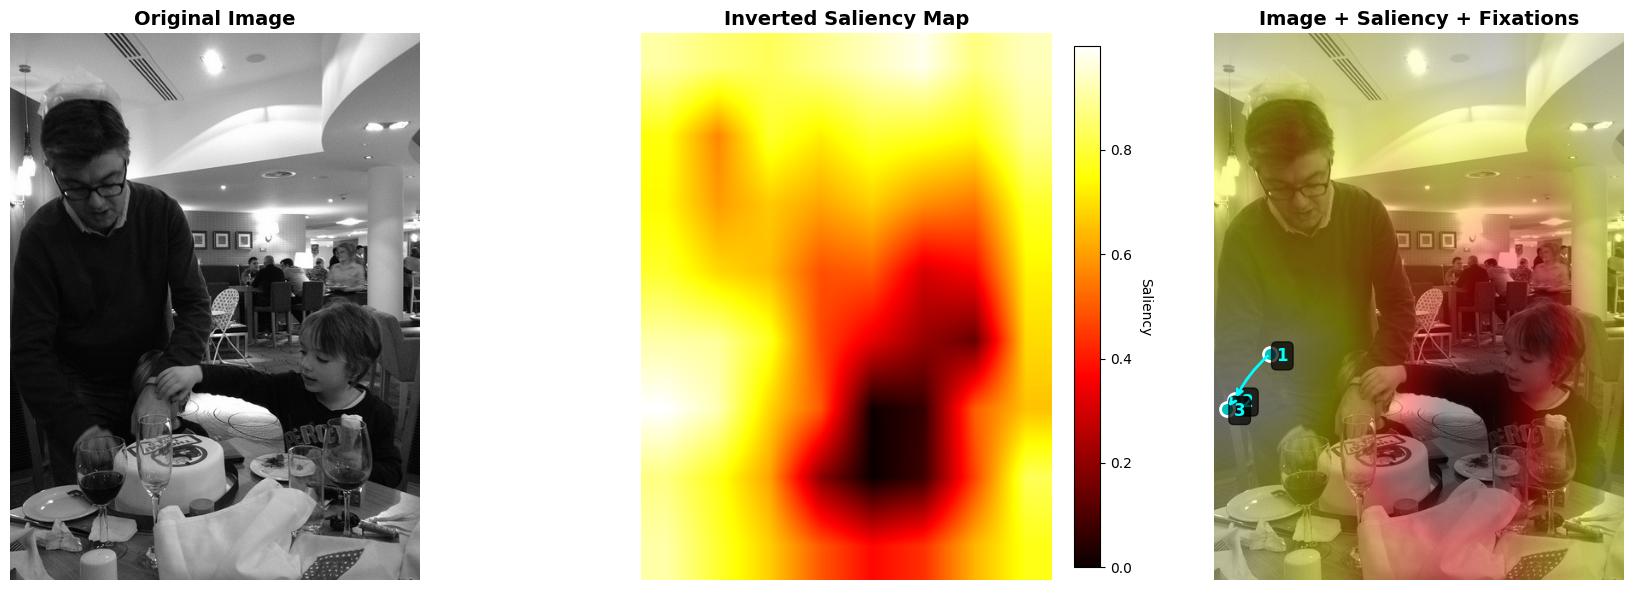

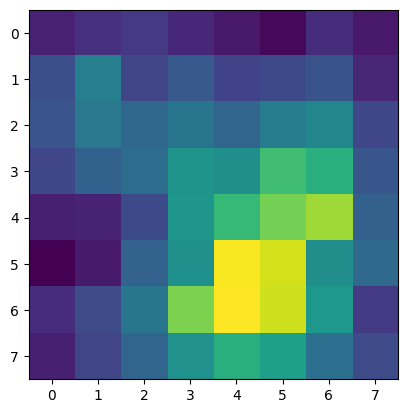

  Fixations: 3
    Fixation 1: (22, 304) - Distance: 264.0px
    Fixation 2: (20, 370) - Distance: 329.3px
    Fixation 3: (20, 414) - Distance: 372.8px
  Final distance to target: 372.8 pixels


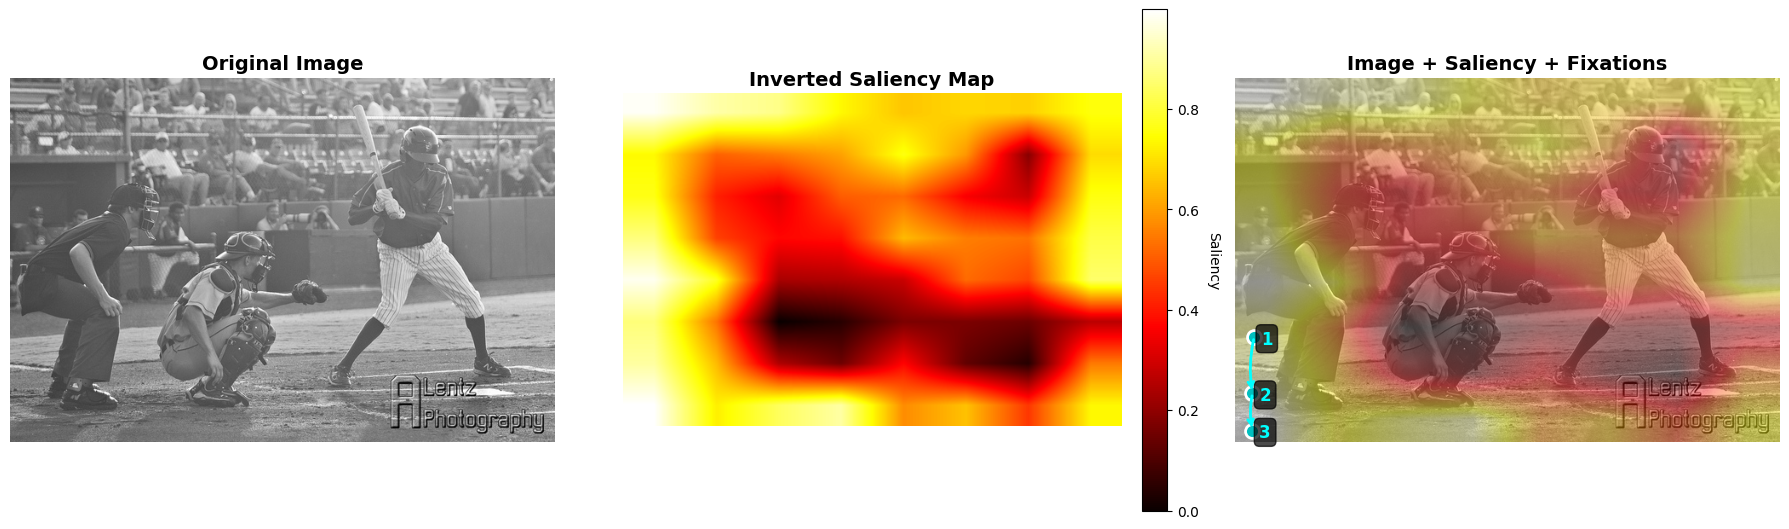

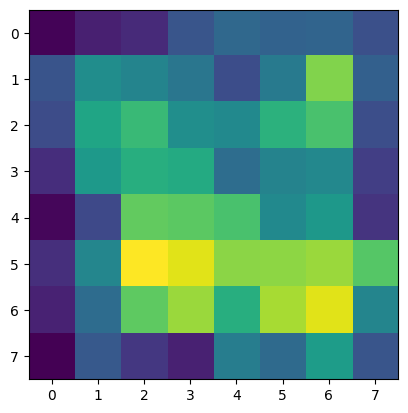

In [25]:
for idx, test_image in enumerate(test_images):
    bbox = test_image["bbox_dict"]
    target_location = (int((bbox['x1'] + bbox['x2']) / 2), int((bbox['y1'] + bbox['y2']) / 2))

    image = np.array(test_image["image"])
    saliency, saliency_upsampled, fixations = model.visual_search(image)

    # Calculate performance metrics
    final_fixation = fixations[-1]
    distance_to_target = np.sqrt(
        (final_fixation[0] - target_location[0])**2 +
        (final_fixation[1] - target_location[1])**2
    )

    print(f"  Fixations: {len(fixations)}")
    for i, (x, y) in enumerate(fixations):
        dist = np.sqrt((x - target_location[0])**2 + (y - target_location[1])**2)
        print(f"    Fixation {i+1}: ({x}, {y}) - Distance: {dist:.1f}px")

    print(f"  Final distance to target: {distance_to_target:.1f} pixels")

    # Visualize results
    model.visualize_search(image, saliency_upsampled.squeeze(0), fixations)
    plt.figure()
    plt.imshow(saliency.detach().cpu().numpy().squeeze(0))
    plt.show()